<a href="https://colab.research.google.com/github/vituhaa/Healthy-Posture/blob/project/EfficientNetB0_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Работа с EfficientNetB0

Transfer learning tutorial - https://www.tensorflow.org/tutorials/images/transfer_learning

In [1]:
import shutil
import os
import cv2
import numpy as np
import seaborn as sns
import tensorflow as tf
from matplotlib import pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.applications import EfficientNetB0
from keras import layers
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, Rescaling, Input

In [2]:
from google.colab import drive
drive.mount('content/')

Mounted at content/


In [3]:
# # операция проведена один раз для копирования файлов из старого датасета в новый
# from_folder = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/MoveNet_MLP_dataset'
# new_folder = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_dataset'

# from_test_path = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/MoveNet_Test'
# to_test_path = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_Test'

# folders_names = {
#     'bend_over': 'bad',
#     'body_left': 'bad',
#     'body_right': 'bad',
#     'head_left': 'bad',
#     'head_right': 'bad',
#     'too_close': 'bad',
#     'tilt_back': 'bad',
#     'correct': 'good'
# }

# for prev_category, new_category in folders_names.items():
#   prev_path = os.path.join(from_folder, prev_category)
#   new_path = os.path.join(new_folder, new_category)

#   prev_test_path = os.path.join(from_test_path, prev_category)
#   new_test_path = os.path.join(to_test_path, new_category)

#   os.makedirs(new_path, exist_ok=True)
#   os.makedirs(new_test_path, exist_ok=True)

#   for photo in os.listdir(prev_path):
#     old_photo = os.path.join(prev_path, photo)
#     new_photo = os.path.join(new_path, photo)
#     if os.path.exists(new_photo):
#       photo_name, photo_type = os.path.splitext(new_photo)
#       count = 1
#       while (os.path.exists(os.path.join(new_path, f"{photo_name}_{count}{photo_type}"))):
#         count += 1
#       new_photo = os.path.join(new_path, f"{photo_name}_{count}{photo_type}")
#     shutil.copy2(old_photo, new_photo)

#   for photo in os.listdir(prev_test_path):
#     old_photo = os.path.join(prev_test_path, photo)
#     new_photo = os.path.join(new_test_path, photo)
#     if os.path.exists(new_photo):
#       photo_name, photo_type = os.path.splitext(new_photo)
#       count = 1
#       while (os.path.exists(os.path.join(new_test_path, f"{photo_name}_{count}{photo_type}"))):
#         count += 1
#       new_photo = os.path.join(new_test_path, f"{photo_name}_{count}{photo_type}")
#     shutil.copy2(old_photo, new_photo)

In [4]:
bad_path = '/content/content/MyDrive/datasets_for_3course/EfficientNetB0_dataset/bad'
good_path = '/content/content/MyDrive/datasets_for_3course/EfficientNetB0_dataset/good'

print(len(os.listdir(good_path)))
print(len(os.listdir(bad_path)))

ds_dir = '/content/content/MyDrive/datasets_for_3course/EfficientNetB0_dataset/'
test_path = '/content/content/MyDrive/datasets_for_3course/EfficientNetB0_Test'

1537
1562


In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    ds_dir,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    ds_dir,
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# подготовка данных
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [ ]:
base_model = EfficientNetB0(input_shape=(224, 224, 3),
                            include_top=False,
                            weights='imagenet')

base_model.trainable = False

model = Sequential([
    base_model,
    augmentation,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])
optimizer = keras.optimizers.Adam(learning_rate=0.001)
loss = keras.losses.BinaryCrossentropy(from_logits=False)
model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

checkpoint = 'tl_EfficientNetB0.h5'
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max'
)

In [ ]:
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=15,
                    callbacks=[checkpoint_callback]
                    )

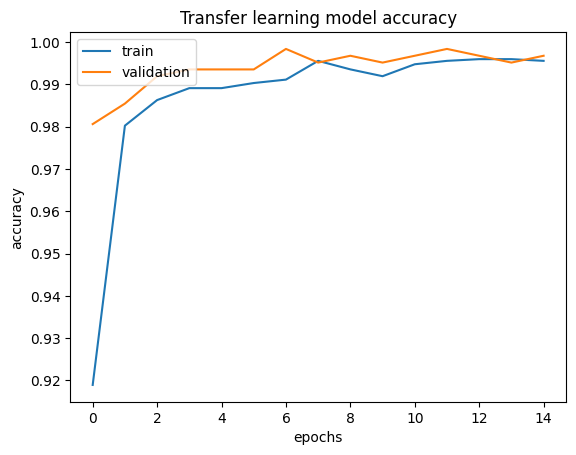

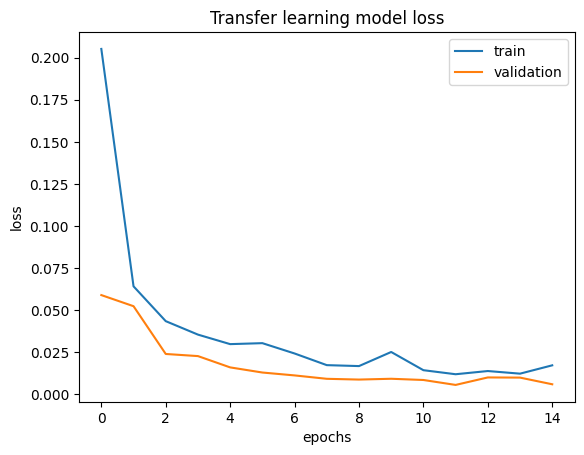

In [8]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Transfer learning model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend(["train", "validation"], loc="upper left")
plt.show()

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Transfer learning model loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(["train", "validation"], loc="upper right")
plt.show()

In [9]:
!ls

content  drive	sample_data  tl_EfficientNetB0.h5


Accuracy:  0.8
Precision:  0.8
Recall:  0.8


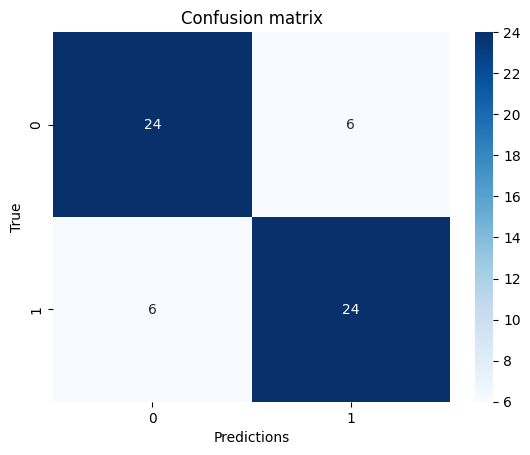

In [10]:
import seaborn as sns

saved_model = tf.keras.models.load_model('tl_EfficientNetB0.h5')

true_categories = []
pred_categories = []
for classes in os.listdir(test_path):
  class_path = test_path + '/' + classes
  for photo in os.listdir(class_path):
    # print(photo)
    photo_path = test_path + '/' + classes + '/' + photo
    # print(photo_path, classes)
    true_categories.append(classes)
    img = cv2.imread(photo_path)
    img = cv2.resize(img, (224, 224))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    prediction = saved_model.predict(img, verbose=0)[0][0]
    # print(prediction)
    category = 0
    if prediction >= 0.5:
      category = 1
    else:
      category = 0
    pred_categories.append(category)

true_labels = []
for x in true_categories:
  if x == 'bad':
    true_labels.append(0)
  else:
    true_labels.append(1)

accuracy = accuracy_score(pred_categories, true_labels)
precision = precision_score(pred_categories, true_labels)
recall = recall_score(pred_categories, true_labels)

print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)

matrix = confusion_matrix(true_labels, pred_categories)
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predictions')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

Custom CNN: A lightweight Convolutional Neural Network built from scratch. The architecture consists of three convolutional blocks with MaxPooling, followed by a dense classifier with a Dropout layer for regularization.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization, Rescaling, Input

train_ds_cnn = tf.keras.utils.image_dataset_from_directory(
    ds_dir,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds_cnn = tf.keras.utils.image_dataset_from_directory(
    ds_dir,
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    batch_size=32,
    image_size=(224, 224),
    shuffle=False
)

# подготовка данных
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

augmentation_cnn = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

filers_size = (3, 3)

custom_model = Sequential([
    Input(shape=(224, 224, 3)),
    Rescaling(1./255),
    augmentation_cnn,
    Conv2D(32, filers_size, activation='relu', padding='same'),
    MaxPooling2D(),

    Conv2D(64, filers_size, activation='relu', padding='same'),
    MaxPooling2D(),

    Conv2D(128, filers_size, activation='relu', padding='same'),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.001)
loss = keras.losses.BinaryCrossentropy(from_logits=False)
custom_model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

checkpoint = 'custom_cnn_model.h5'
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint,
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max'
)

history_cnn = custom_model.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=15,
    callbacks=[checkpoint_callback]
)

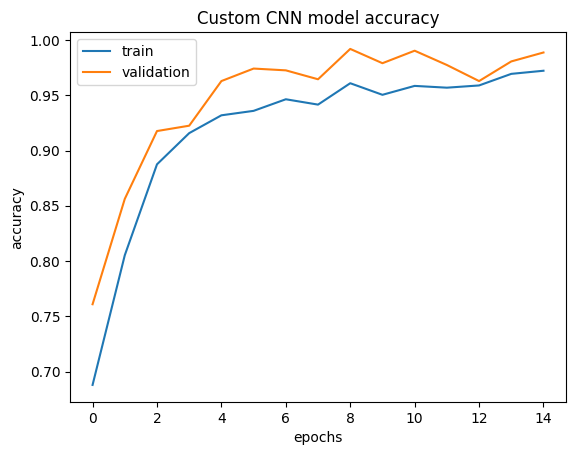

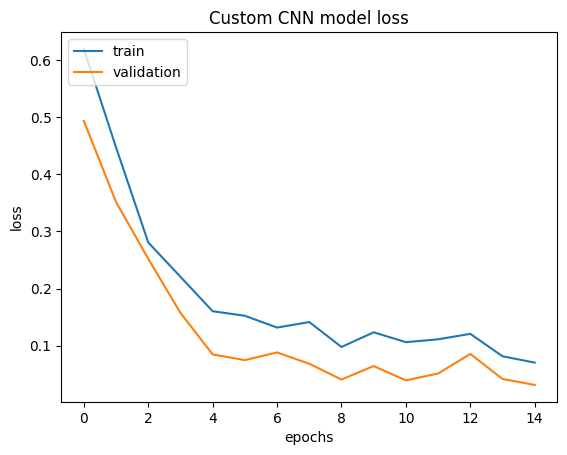

In [12]:
plt.plot(history_cnn.history["accuracy"])
plt.plot(history_cnn.history["val_accuracy"])
plt.title("Custom CNN model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend(["train", "validation"], loc="upper left")
plt.show()

plt.plot(history_cnn.history["loss"])
plt.plot(history_cnn.history["val_loss"])
plt.title("Custom CNN model loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(["train", "validation"], loc="upper left")
plt.show()

Accuracy:  0.7666666666666667
Precision:  0.5666666666666667
Recall:  0.9444444444444444


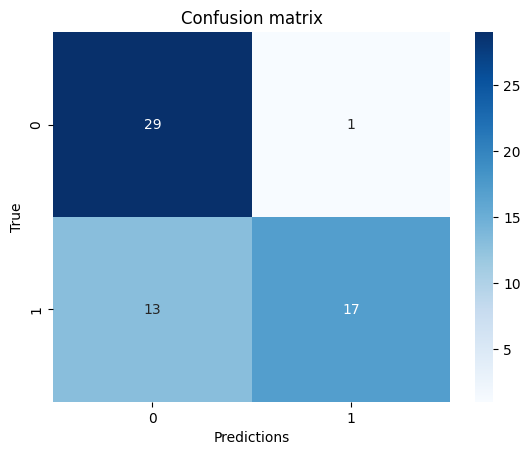

In [13]:
saved_cnn_model = tf.keras.models.load_model('custom_cnn_model.h5')

true_categories = []
pred_categories = []
for classes in os.listdir(test_path):
  class_path = test_path + '/' + classes
  for photo in os.listdir(class_path):
    # print(photo)
    photo_path = test_path + '/' + classes + '/' + photo
    # print(photo_path, classes)
    true_categories.append(classes)
    img = cv2.imread(photo_path)
    img = cv2.resize(img, (224, 224))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    prediction = saved_cnn_model.predict(img, verbose=0)[0][0]
    # print(prediction)
    category = 0
    if prediction >= 0.5:
      category = 1
    else:
      category = 0
    pred_categories.append(category)

true_labels = []
for x in true_categories:
  if x == 'bad':
    true_labels.append(0)
  else:
    true_labels.append(1)

accuracy = accuracy_score(pred_categories, true_labels)
precision = precision_score(pred_categories, true_labels)
recall = recall_score(pred_categories, true_labels)

print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)

matrix = confusion_matrix(true_labels, pred_categories)
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predictions')
plt.ylabel('True')
plt.title('Confusion matrix')
plt.show()

In [14]:
!ls

content  custom_cnn_model.h5  drive  sample_data  tl_EfficientNetB0.h5
